Measuring Cosmological Parameters Using Type Ia Supernovae.

In [95]:
import warnings 
warnings.filterwarnings('ignore')

In [168]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import astropy.constants as const 
from scipy.optimize import curve_fit 
from scipy.integrate import quad 
from astropy import units as u 
from astropy.cosmology import Planck18 as cosmo


In [97]:
# Local file path
file_path = "D:\Data\pantheon\Pantheon+SH0ES.dat"

# Load the file
data = pd.read_csv("D:\Data\pantheon\Pantheon+SH0ES.dat",delim_whitespace= True , comment = '#')

# See structure
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1701 entries, 0 to 1700
Data columns (total 47 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CID                   1701 non-null   object 
 1   IDSURVEY              1701 non-null   int64  
 2   zHD                   1701 non-null   float64
 3   zHDERR                1701 non-null   float64
 4   zCMB                  1701 non-null   float64
 5   zCMBERR               1701 non-null   float64
 6   zHEL                  1701 non-null   float64
 7   zHELERR               1701 non-null   float64
 8   m_b_corr              1701 non-null   float64
 9   m_b_corr_err_DIAG     1701 non-null   float64
 10  MU_SH0ES              1701 non-null   float64
 11  MU_SH0ES_ERR_DIAG     1701 non-null   float64
 12  CEPH_DIST             1701 non-null   float64
 13  IS_CALIBRATOR         1701 non-null   int64  
 14  USED_IN_SH0ES_HF      1701 non-null   int64  
 15  c                    

In [98]:
red_shift = data['zHD']
distance_modulus = data['MU_SH0ES']
uncertainity = data['MU_SH0ES_ERR_DIAG']

In [99]:
filtered_data = data[['zHD', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']].dropna()
filtered_data.to_numpy()

array([[1.22000e-03, 2.89987e+01, 1.51645e+00],
       [1.22000e-03, 2.90559e+01, 1.51747e+00],
       [2.56000e-03, 3.07233e+01, 7.82372e-01],
       ...,
       [1.80119e+00, 4.54865e+01, 2.81981e-01],
       [1.91165e+00, 4.54233e+01, 3.58642e-01],
       [2.26137e+00, 4.61828e+01, 2.81309e-01]])

In [100]:
filtered_data

,zHD,MU_SH0ES,MU_SH0ES_ERR_DIAG
0,0.00122,28.9987,1.516450
1,0.00122,29.0559,1.517470
2,0.00256,30.7233,0.782372
3,0.00256,30.7449,0.799068
4,0.00299,30.7757,0.881212
...,...,...,...
1696,1.61505,45.1595,0.333024
1697,1.69706,45.2863,0.380480
1698,1.80119,45.4865,0.281981
1699,1.91165,45.4233,0.358642


Hubble Diagram

In [ ]:

import matplotlib as mpl

# Use a publication-style font and settings
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 300
})

# Create figure and axis
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Main plot with error bars
ax.errorbar(red_shift, distance_modulus, yerr= uncertainity, fmt='o', markersize=1.5, capsize=0.5,
            color='blue', ecolor='red', elinewidth=1, markeredgewidth=0.5,
            label='Pantheon+SH0ES SNe')

# Log scale on x-axis
ax.set_xscale('log')

# Labels and title
ax.set_xlabel('Redshift $z$')
ax.set_ylabel('Distance Modulus $\\mu$')
ax.set_title('Hubble Diagram')

# Grid styling
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Minor ticks
ax.tick_params(which='both', direction='in', top=True, right=True)

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

# Legend
ax.legend(frameon=False)

# Tight layout for no clipping
plt.tight_layout()
plt.show()


Define cosmological model


In [103]:
z= red_shift

In [104]:
H0 = cosmo.H0
c = const.c
Mpc = 3.085677581e22

In [171]:
H0

<Quantity 67.66 km / (Mpc s)>

In [159]:

# Define the E(z) for flat LCDM
def E(z, Omega_m):
    return np.sqrt(Omega_m*(1+z)**3 + (1- Omega_m))

# Luminosity distance in Mpc, try using scipy quad to integrate.
def luminosity_distance(z, H0, Omega_m):
    H0 = H0 * u.km / u.s / u.Mpc
    integral,_= quad(lambda z_prime: 1 / E(z_prime, Omega_m),0,z)
    dL=(c/H0)*(1 + z)*integral
    return dL.to(u.Mpc).value

# Theoretical distance modulus, use above function inside mu_theory to compute luminosity distance 
def mu_theory(z, H0, Omega_m):
    dL_mpc= luminosity_distance(z, H0, Omega_m)
    return 5* np.log10(dL_mpc)+ 25 

In [160]:
def mu_model_for_fit(z_array, H0, Omega_m):
    return np.array([mu_theory(z, H0, Omega_m) for z in z_array])

In [161]:
initial_guess = [70, 0.3]

popt, pcov = curve_fit(
    mu_model_for_fit,
    z,
    distance_modulus,
    sigma=uncertainity,
    p0=initial_guess,
    absolute_sigma=True,
    maxfev = 10000
)

H0_fit, Omega_m_fit = popt
H0_err, Omega_m_err = np.sqrt(np.diag(pcov))

In [162]:
print(f"Best-fit H0: {H0_fit:.2f} ± {H0_err:.2f} km/s/Mpc")
print(f"Best-fit Omega_m: {Omega_m_fit:.3f} ± {Omega_m_err:.3f}")

Best-fit H0: 72.97 ± 0.26 km/s/Mpc
Best-fit Omega_m: 0.351 ± 0.019


In [182]:
def age_of_universe(H0, Omega_m):
    H0_si = H0 * (u.km / u.s / u.Mpc)  # Convert H0 to 1/s

    def integrand(z):
        Ez = np.sqrt(Omega_m * (1 + z)**3 + (1 - Omega_m))
        return 1.0 / ((1 + z) * Ez)

    integral, _ = quad(integrand, 0, np.inf)
    age_seconds = integral / H0_si.to(1 / u.s).value
    age_gyr = (age_seconds * u.s).to(u.Gyr).value
    return age_gyr
    
t0 = age_of_universe(H0_fit, Omega_m_fit)
print(f"Estimated age of Universe: {t0:.2f} Gyr")

Estimated age of Universe: 12.36 Gyr


In [189]:
# Define the E(z) for flat LCDM
def E(z, Omega_m):
    return np.sqrt(Omega_m*(1+z)**3 + (1- Omega_m))

# Luminosity distance in Mpc, try using scipy quad to integrate.
def luminosity_distance(z, H0, Omega_m):
    H0 = H0 * u.km / u.s / u.Mpc
    integral,_= quad(lambda z_prime: 1 / E(z_prime, Omega_m),0,z)
    dL=(c/H0)*(1 + z)*integral
    return dL.to(u.Mpc).value

# Theoretical distance modulus, use above function inside mu_theory to compute luminosity distance 
def mu_theory(z, H0, Omega_m):
    dL_mpc= luminosity_distance(z, H0, Omega_m)
    return 5* np.log10(dL_mpc)+ 25
    
mu_model = np.array([mu_theory(zi, H0_fit, Omega_m_fit) for zi in z])

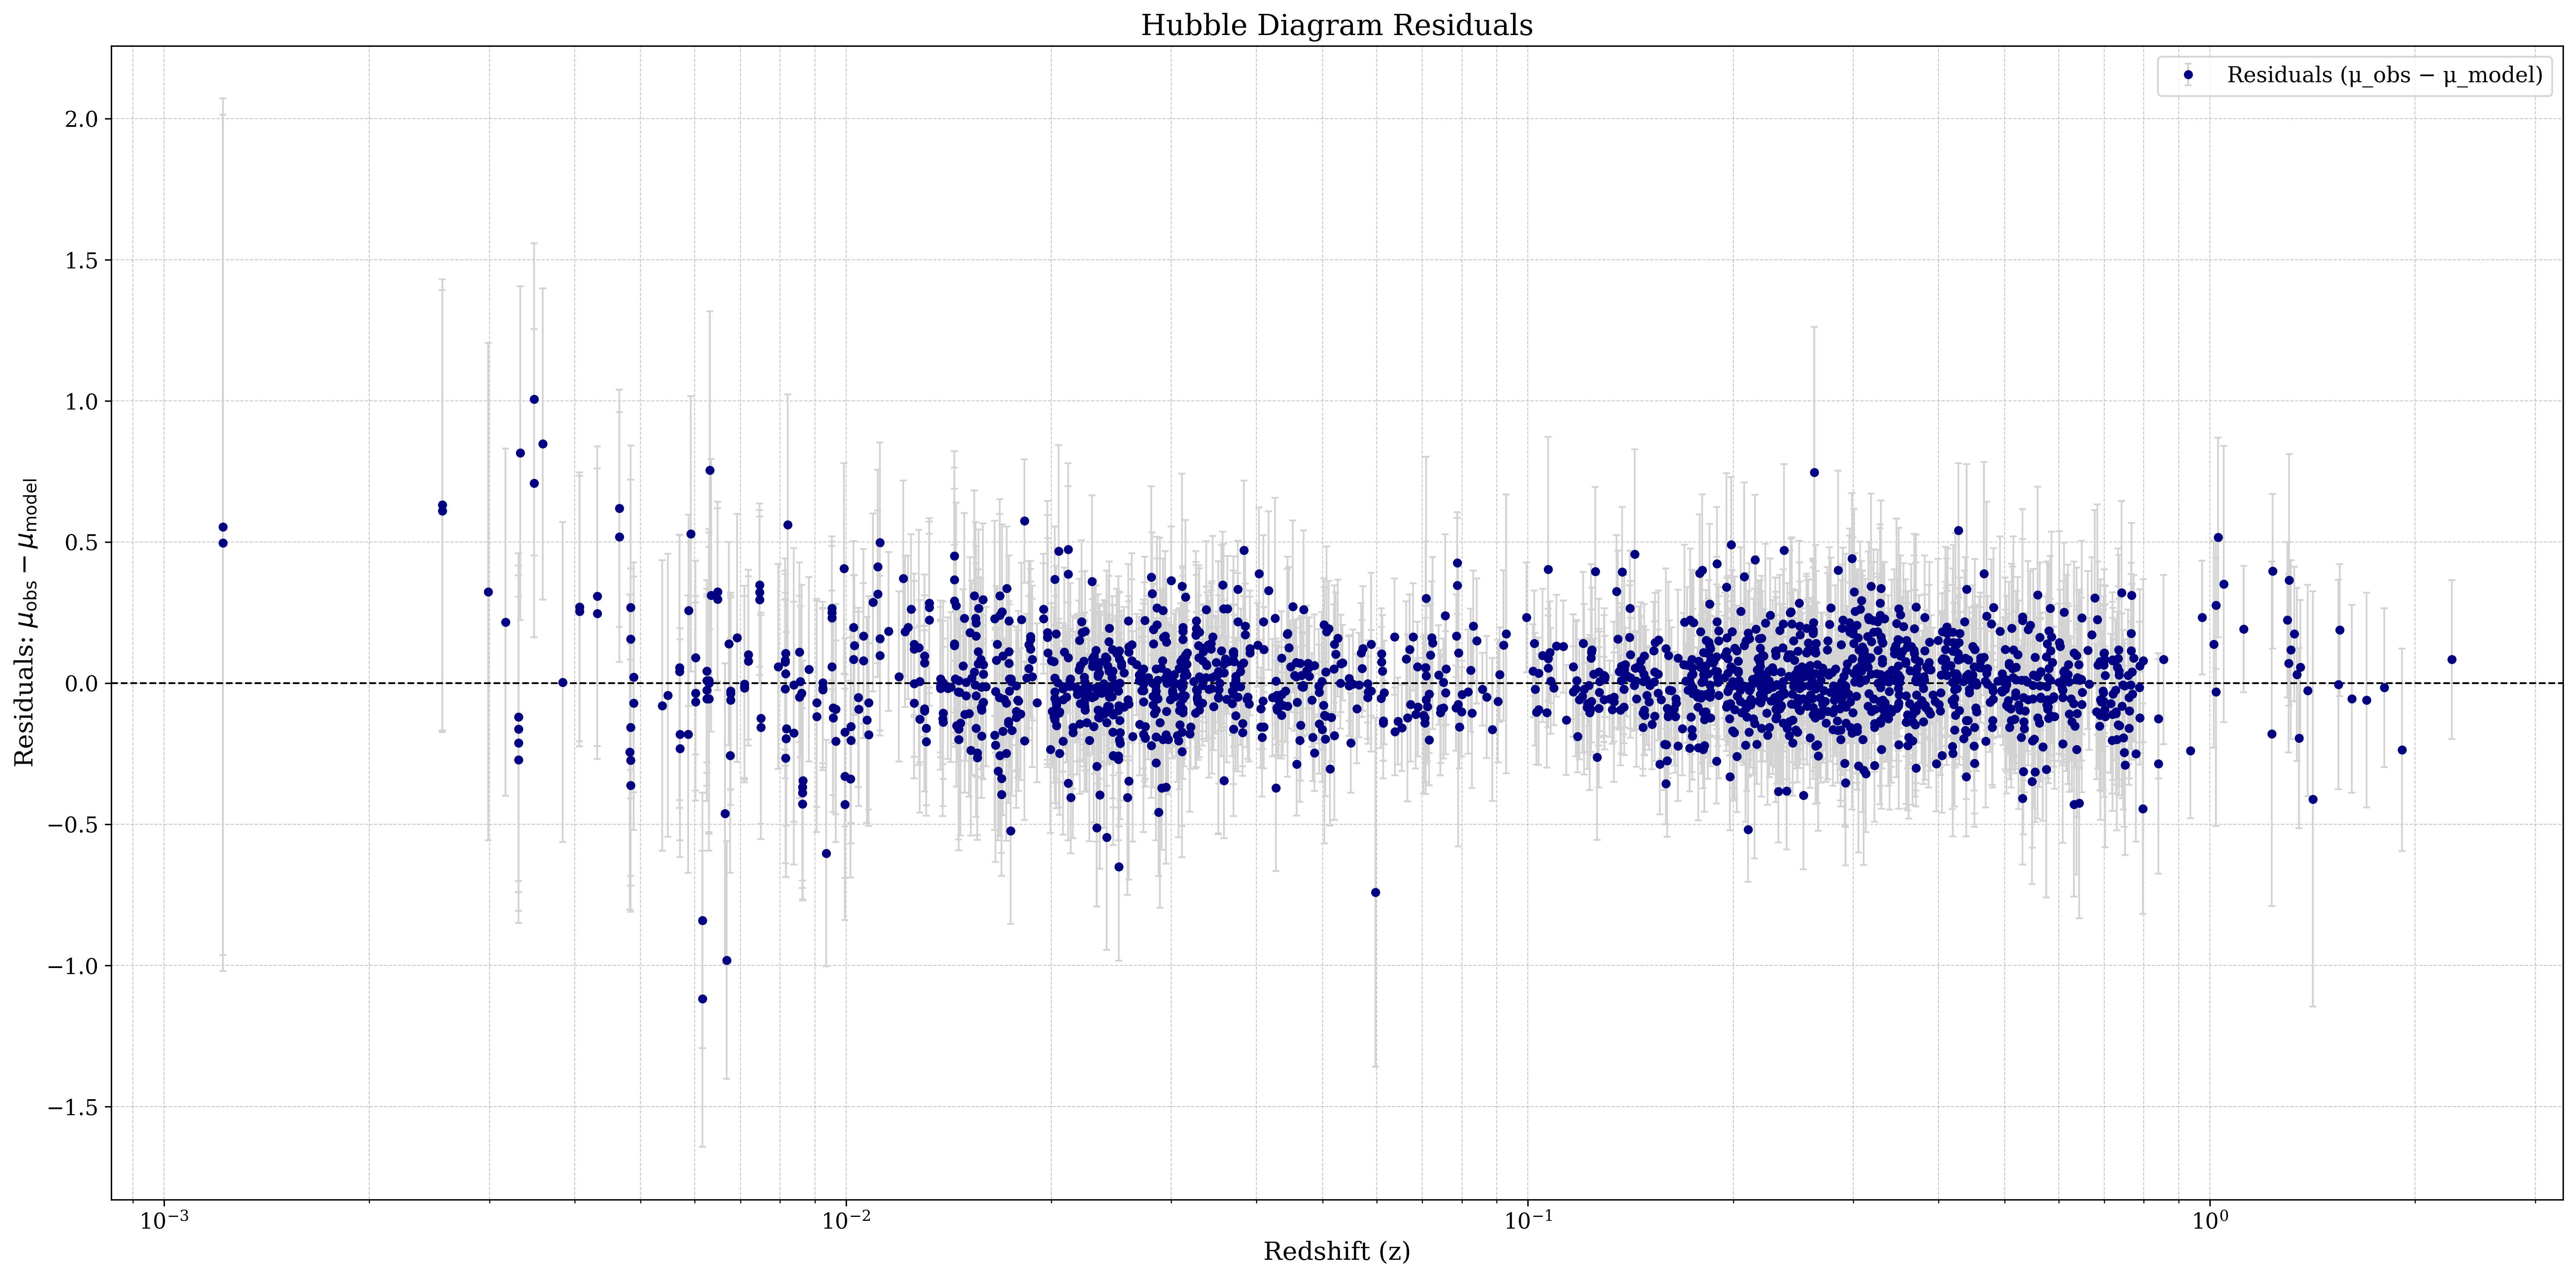

In [192]:

residuals = distance_modulus - mu_model

fig, ax = plt.subplots(figsize=(20,10))

ax.errorbar(
    z, residuals, yerr=uncertainity, fmt='o', markersize=4,
    color='navy', ecolor='lightgray', elinewidth=1, capsize=2,
    label='Residuals (μ_obs − μ_model)'
)

ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.set_xscale('log')

# Axis labels and title
ax.set_xlabel('Redshift (z)', fontsize=14)
ax.set_ylabel(r'Residuals: $\mu_{\mathrm{obs}} - \mu_{\mathrm{model}}$', fontsize=14)
ax.set_title('Hubble Diagram Residuals', fontsize=16)

# Ticks and grid
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Add legend
ax.legend(fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()


In [193]:
def mu_fixed_Om(z, H0):
    return np.array([mu_theory(zi, H0, Omega_m=0.3) for zi in z])  # z is array, zi is scalar

initial_guess = [70]

popt, pcov = curve_fit(
    mu_fixed_Om,
    z,                      
    distance_modulus,       
    sigma=uncertainity,     
    p0=initial_guess,
    absolute_sigma=True
)

H0_fit_fixed = popt[0]
H0_err_fixed = np.sqrt(pcov[0][0])

print(f"Best-fit H0 (fixed Ωm=0.3): {H0_fit_fixed:.2f} ± {H0_err_fixed:.2f} km/s/Mpc")


Best-fit H0 (fixed Ωm=0.3): 73.53 ± 0.17 km/s/Mpc


In [209]:
z_split = 0.1
low_z_mask = z< z_split
high_z_mask = z >= z_split

z_low = z[low_z_mask]
mu_low = distance_modulus[low_z_mask]
err_low = uncertainity[low_z_mask]

z_high = z[high_z_mask]
mu_high = distance_modulus[high_z_mask]
err_high = uncertainity[high_z_mask]

popt_low, pcov_low = curve_fit(mu_fixed_Om, z_low, mu_low, sigma=err_low, p0=[70], absolute_sigma=True)
H0_low = popt_low[0]
H0_err_low = np.sqrt(pcov_low[0][0])

popt_high, pcov_high = curve_fit(mu_fixed_Om, z_high, mu_high, sigma=err_high, p0=[70], absolute_sigma=True)
H0_high = popt_high[0]
H0_err_high = np.sqrt(pcov_high[0][0])




In [210]:
print(f"Low-z (z < {z_split}): H₀ = {H0_low:.2f} km/s/Mpc")
print(f"High-z (z ≥ {z_split}): H₀ = {H0_high:.2f} km/s/Mpc")


Low-z (z < 0.1): H₀ = 73.01 km/s/Mpc
High-z (z ≥ 0.1): H₀ = 73.85 km/s/Mpc
